<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/Support_Vector_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (3333, 11)

First 5 Rows:
   Churn  AccountWeeks  ContractRenewal  DataPlan  DataUsage  CustServCalls  \
0      0           128                1         1        2.7              1   
1      0           107                1         1        3.7              1   
2      0           137                1         0        0.0              0   
3      0            84                0         0        0.0              2   
4      0            75                0         0        0.0              3   

   DayMins  DayCalls  MonthlyCharge  OverageFee  RoamMins  
0    265.1       110           89.0        9.87      10.0  
1    161.6       123           82.0        9.78      13.7  
2    243.4       114           52.0        6.06      12.2  
3    299.4        71           57.0        3.10       6.6  
4    166.7       113           41.0        7.42      10.1  

Class Distribution:
Churn
0    2850
1     483
Name: count, dtype: int64

Class Percentage:
Churn
0    85.508551
1    14.491

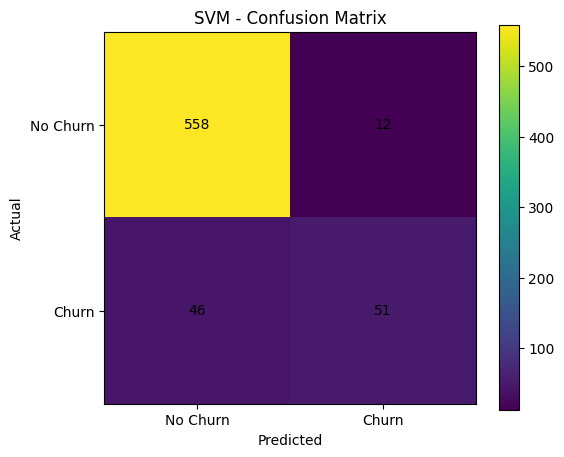

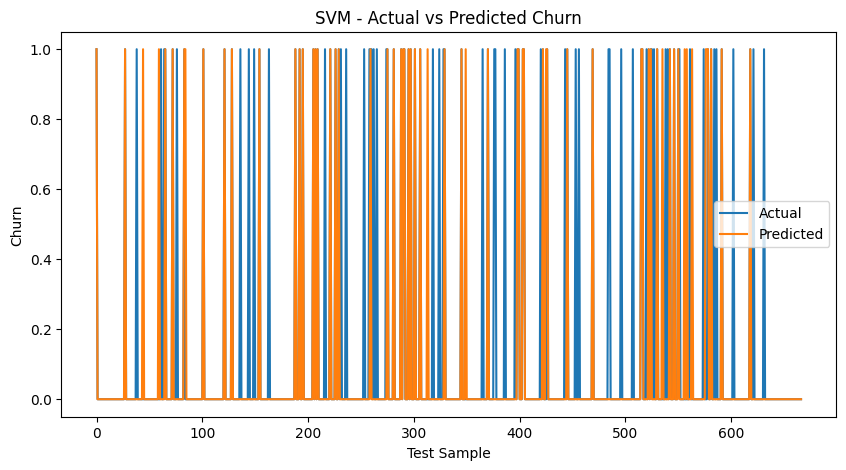

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv("telecom_churn.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())


# ==========================================
# 2. CHECK CLASS DISTRIBUTION
# ==========================================

print("\nClass Distribution:")
print(df["Churn"].value_counts())

print("\nClass Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)


# ==========================================
# 3. SEPARATE FEATURES AND TARGET
# ==========================================

X = df.drop("Churn", axis=1)
y = df["Churn"]


# ==========================================
# 4. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ==========================================
# 5. FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==========================================
# 6. CREATE SVM MODEL
# ==========================================

model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)


# ==========================================
# 7. TRAIN MODEL
# ==========================================

model.fit(X_train, y_train)


# ==========================================
# 8. PREDICTION
# ==========================================

y_pred = model.predict(X_test)

# Probability for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]


# ==========================================
# 9. MODEL EVALUATION
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


print("\n======================================")
print("SVM RESULTS")
print("======================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


# ==========================================
# 10. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ==========================================
# 11. CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ==========================================
# 12. CONFUSION MATRIX GRAPH
# ==========================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.yticks(
    [0, 1],
    ["No Churn", "Churn"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()


# ==========================================
# 13. ACTUAL VS PREDICTED GRAPH
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    y_pred,
    label="Predicted"
)

plt.xlabel("Test Sample")
plt.ylabel("Churn")
plt.title("SVM - Actual vs Predicted Churn")

plt.legend()

plt.show()